In [126]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [127]:
import pandas as pd

In [128]:
#cargamos el archivo especificando encoding latin-1
df = pd.read_csv("netflix_titles.csv", encoding="latin-1")

#eliminamos las columnas 'Unnamed' vacias generadas por comas
columnas_validas = [col for col in df.columns if not col.startswith("Unnamed")]
df = df[columnas_validas]

#cambiamos a UTF-8
df.to_csv("netflix_titles.csv", index=False, encoding="utf-8")

In [129]:
from matplotlib import pyplot as plt

In [130]:
data_2000 = df[df['release_year'] >= 2000]
#data = df

Inciso a

Indicar el número de películas del catálogo según su año de lanzamiento.


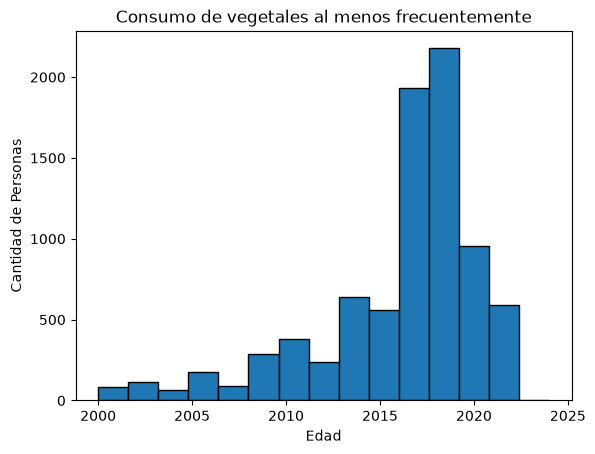

In [131]:
plt.hist(data['release_year'], bins=15, edgecolor='black', label="Personas que comen vegetales")
plt.xlabel('Edad')
plt.ylabel('Cantidad de Personas')
plt.title('Consumo de vegetales al menos frecuentemente')
plt.show()

Inciso b

Ídem pero utilizando sólamente TV Shows.

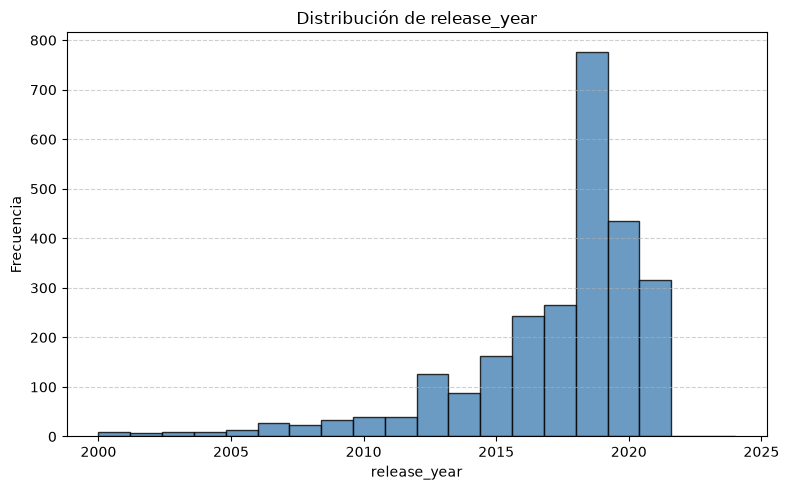

In [132]:
data_b = data[data['type'] == 'TV Show']

utils.histograma(data_b, 'release_year', 20)

Inciso c

Estudiar la cantidad de películas y TV Shows del catálogo según su rating.

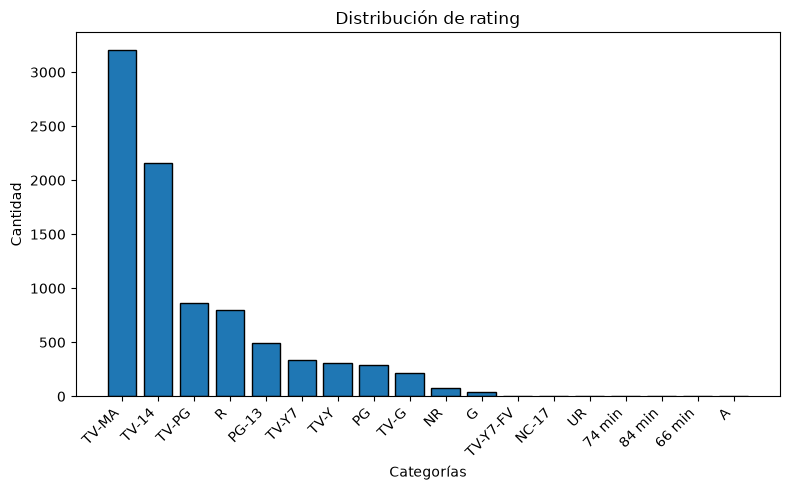

In [133]:
utils.barras('rating', dat_c)

Inciso d

Estudiar la relación entre rating y duración de la película y/o serie

In [134]:
df['rating'].value_counts()

rating
TV-MA       3208
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
A              1
Name: count, dtype: int64

In [135]:
df = df.dropna(subset=['duration'])

In [136]:

df['duration'] = df['duration'].str.split().str[0].astype(int)

In [137]:
df.info()

<class 'pandas.DataFrame'>
Index: 8806 entries, 0 to 8808
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8806 non-null   str  
 1   type          8806 non-null   str  
 2   title         8806 non-null   str  
 3   director      6172 non-null   str  
 4   cast          7981 non-null   str  
 5   country       7975 non-null   str  
 6   date_added    8796 non-null   str  
 7   release_year  8806 non-null   int64
 8   rating        8802 non-null   str  
 9   duration      8806 non-null   int64
 10  listed_in     8806 non-null   str  
 11  description   8806 non-null   str  
dtypes: int64(2), str(10)
memory usage: 894.4 KB


In [138]:
df[df['type'] == 'Movie']['duration'].value_counts()

duration
90     152
94     146
97     146
93     146
91     144
      ... 
228      1
18       1
205      1
201      1
191      1
Name: count, Length: 205, dtype: int64

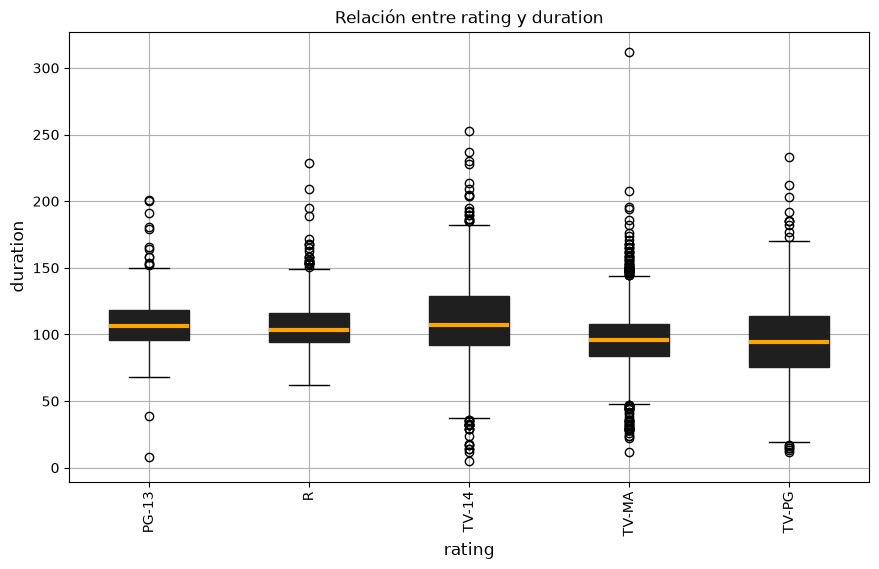

In [139]:
pelis = df[df['type'] == 'Movie']

#pelis['duration'].value_counts()

conteo = pelis['rating'].value_counts()

pelis = pelis[pelis['rating'].map(conteo) > 400]
utils.box_plot('rating', 'duration', pelis)

Inciso e

Estudiar la cantidad de palabras en la descripción y el rating. ¿Podemos decir que las películas con descripciones más largas están mejor votadas?

Inciso f

Graficar el número de películas y TV shows por separado, según su país de origen.

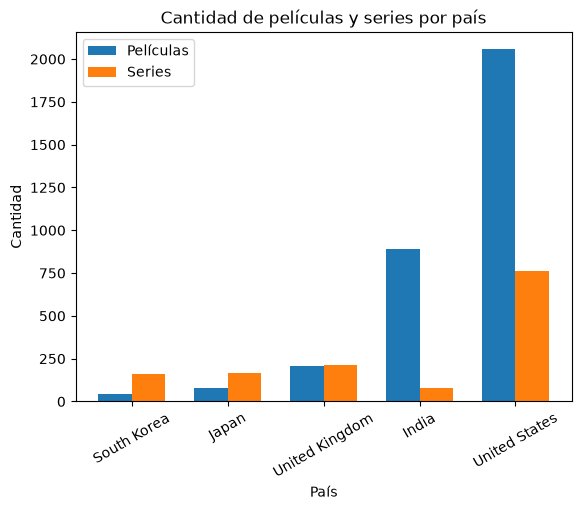

In [140]:
#nos quedamos con los paises que al menos tienen mas de 200 peliculas o series.
conteo = df['country'].value_counts()
country_200 = df[df['country'].map(conteo) >= 200]

#calculamos la frecuencia por cada grupo pais y tipo, es decir, tendriamos por ejemplo (estados unidos - peli) y (estados unidos - serie).
# con size obtenemos la frecuencia del grupo y ademas, convertimos el tipo a columna para poder accederlo.
frecuencia = country_200.groupby(['country', 'type']).size().unstack(fill_value=0)
frecuencia = frecuencia.sort_values('Movie', ascending=True)

x = frecuencia.index
width = 0.35

#generamos las barras de cada tipo de contenido.
plt.bar(
    [i - width/2 for i in range(len(x))],
    frecuencia['Movie'],
    width,
    label='Películas'
)

plt.bar(
    [i + width/2 for i in range(len(x))],
    frecuencia['TV Show'],
    width,
    label='Series'
)

plt.xlabel("País")
plt.ylabel("Cantidad")
plt.title("Cantidad de películas y series por país")
plt.xticks(range(len(x)), x, rotation=30)
plt.legend()

plt.show()

In [141]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Inciso g

Graficar la cantidad de contenidos por actor del casting (solamente los 10 actores y actrices que más figuran).

<Axes: title={'center': 'Peliculas por actor'}, xlabel='cast', ylabel='Cantidad'>

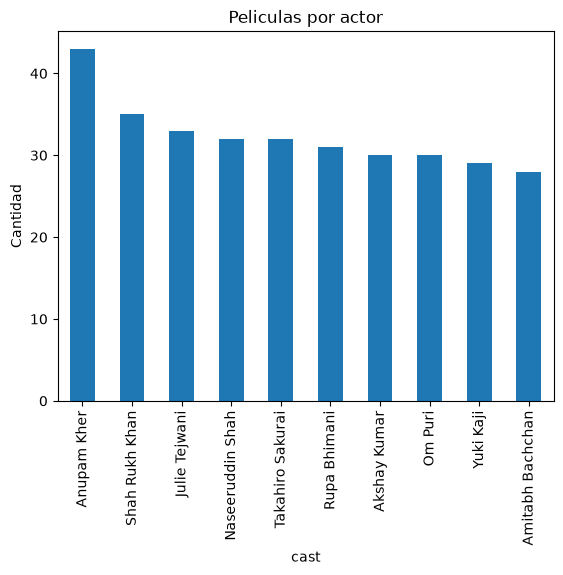

In [142]:
# con esto conseguimos separar por comas y considerar individualmente para dsp contar.
frecuencias_actores = (
    df['cast']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)
frecuencias_actores = frecuencias_actores.sort_values(ascending=False).head(10)
plt.ylabel("Cantidad")
plt.title("Peliculas por actor")
plt.xticks(rotation=90)
frecuencias_actores.plot(kind='bar')

